### Install and Import Libraries and Connect to the database

**Let us first install and import the necessary libraries needed and then load the SQL extension and establish a connection with the database.**




In [ ]:
pip install ipython-sql

In [35]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [80]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
import prettytable 
import sqlite3
from scipy.stats import pearsonr
import numpy as np

In [40]:
%sql sqlite:///socioeconomic.db

In [37]:
con = sqlite3.connect("socioeconomic.db")
cur = con.cursor()

### Store the dataset in a Table

**In this case, the dataset to be analyzed is available as a .CSV (comma separated values) file, perhaps on the internet. To analyze the data using SQL, it first needs to be stored in the database.
We will first read the csv files  from the given url  into pandas dataframes
Next we will be using the  df.to_sql() function to convert each csv file  to a table in sqlite  with the csv data loaded in it.**


In [39]:
df = pd.read_csv ("https://data.cityofchicago.org/resource/jcxq-k9xf.csv")


In [ ]:
data = df.to_sql("SOCIO_ECONOMIC_", con)

In [42]:
prettytable.DEFAULT = "DEFAULT"

In [15]:
%sql SELECT * FROM SOCIO_ECONOMIC_  LIMIT 5;

 * sqlite:///socioeconomic.db
Done.


index,ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
0,1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
1,2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
2,3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
3,4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
4,5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0


## **INSIGHTS**

#### Problem 1
**How many records do we have on our dataset**

In [16]:
%%sql
SELECT COUNT(*)
FROM SOCIO_ECONOMIC_
;

 * sqlite:///socioeconomic.db
Done.


COUNT(*)
78


#### Problem 2

**How many community areas in Chicago have a hardship index greater than 50.0?**


In [17]:
%%sql
SELECT COUNT (*)
FROM SOCIO_ECONOMIC_
WHERE hardship_index > 50.0
;

 * sqlite:///socioeconomic.db
Done.


COUNT (*)
38


#### Problem 3

**What is the maximum value of hardship index in this dataset?**

In [18]:
%%sql
SELECT MAX(hardship_index)
FROM SOCIO_ECONOMIC_
;

 * sqlite:///socioeconomic.db
Done.


MAX(hardship_index)
98.0


#### Problem 4

**Which community area which has the highest hardship index?**


In [19]:
%%sql
SELECT community_area_name
FROM SOCIO_ECONOMIC_
WHERE hardship_index IN
(SELECT MAX(hardship_index)
FROM SOCIO_ECONOMIC_)
;

 * sqlite:///socioeconomic.db
Done.


community_area_name
Riverdale


### Problem 5

#### Which Chicago community areas have per-capita incomes greater than $60,000?

In [24]:
%%sql
SELECT community_area_name
FROM SOCIO_ECONOMIC_
WHERE per_capita_income_ > 60000

;

 * sqlite:///socioeconomic.db
Done.


community_area_name
Lake View
Lincoln Park
Near North Side
Loop


#### Problem 6

**Explain the correlation between the two variables. Create a scatter plot using the variables `per_capita_income_` and `hardship_index`.**

In [54]:
income_hardship_data = %sql SELECT per_capita_income_, hardship_index FROM SOCIO_ECONOMIC_;


 * sqlite:///socioeconomic.db
Done.


In [81]:
clean_df = df[['per_capita_income_', 'hardship_index']].replace([np.inf, -np.inf], np.nan).dropna()
corr_coef, p_value = pearsonr(clean_df['per_capita_income_'], clean_df['hardship_index'])

print(f"Pearson Correlation Coefficient: {corr_coef:.3f}")
print(f"P-value: {p_value:.3e}")

Pearson Correlation Coefficient: -0.849
P-value: 1.726e-22


**The analysis reveals a very strong, statistically significant negative correlation (r = -0.849, p < 0.001) between per capita income and hardship index. This means higher income levels are strongly associated with reduced hardship. The relationship is statistically significant. It is unlikely to have occurred by chance and supports the hypothesis that economic well-being improves as per capita income rises.**

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.7, 1.0, 'r = -0.849\nP = 1.726e-22')

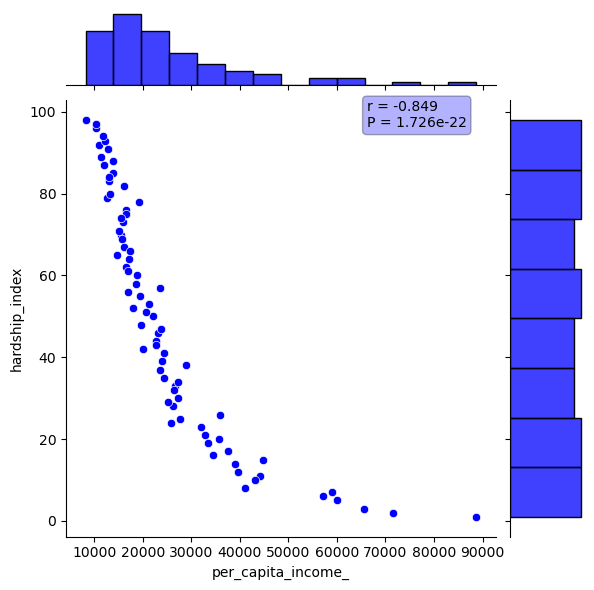

In [79]:
income_hardship_plot = sns.jointplot (x = "per_capita_income_", y = "hardship_index", data = income_hardship_data.DataFrame(), color = "blue")
#print (income_hardship_plot)
income_hardship_plot.ax_joint.annotate(
    f'r = {corr_coef:.3f}\nP = {p_value:.3e}',
    xy=(0.70, 1.00), xycoords='axes fraction',
    ha='left', va='top',
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="blue", alpha=0.3))

**This pattern suggests that income is a strong predictor of hardship: communities with higher per capita income experience substantially less economic strain. 
The correlation here is very close to -1, meaning it is both strong and negative, higher income is strongly associated with lower hardship**.
